# Spatial Transcriptomics Analysis

This example runs **Ageas** on spatial transcriptomics (ST) data from a
regenerating tissue section. It assembles an `AnnData` object with spatial
coordinates from the raw count and annotation tables, applies quality-control
filtering and clustering, and selects the cell clusters that make up a
candidate lineage. `n_kfold_selection` over a `Hangar` panel is then used to
infer the fate bias separating the lineage, and the predicted probabilities are
visualized in both spatial and UMAP embeddings.

In [1]:
import shutil
import logging
import warnings
import pandas as pd
from sklearn.metrics import accuracy_score
from ageas import Hangar, n_kfold_selection
from ageas.tool import Multimodal_Corpus
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import scanpy as sc

/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cnt_path  = "regeneratin/D15_4.ST.exp.tsv"
obs_path  = "regeneratin/D15_4.ST.annot.tsv"
counts_df = pd.read_csv(cnt_path, sep="\t", index_col=0)
obs_df    = pd.read_csv(obs_path, sep="\t")

In [3]:
obs_df.index = counts_df.index
obs_df

,cluster,x,y,ID
CELL.5940,MSN,-1047,2426,CELL.5940
CELL.5953,MSN,-1000,2431,CELL.5953
CELL.5959,MSN,-963,2436,CELL.5959
CELL.5966,MSN,-1100,2446,CELL.5966
CELL.5969,MSN,-1070,2439,CELL.5969
...,...,...,...,...
CELL.11988,VLMC,-1489,5117,CELL.11988
CELL.11989,sstIN,-1443,5117,CELL.11989
CELL.11995,VLMC,-1542,5141,CELL.11995
CELL.12005,nptxEX,-1115,5347,CELL.12005


In [4]:
import scipy.sparse as sp
var_df = pd.DataFrame(index=counts_df.columns)
X = sp.csr_matrix(counts_df.values)
adata = sc.AnnData(X=X, 
                   obs=obs_df,
                   var=var_df)
spatial_cols = ["x", "y"]
has_coord = [c for c in spatial_cols if c in obs_df.columns]
adata.obsm["spatial"] = obs_df[has_coord].to_numpy()

In [5]:

if not isinstance(adata.X, np.ndarray):
    adata.obs['n_genes_by_counts'] = (adata.X > 0).sum(axis=1).A1
    adata.obs['total_counts'] = adata.X.sum(axis=1).A1
print(adata)
print(adata.obs.cluster.value_counts())

AnnData object with n_obs × n_vars = 2396 × 32095
    obs: 'cluster', 'x', 'y', 'ID', 'n_genes_by_counts', 'total_counts'
    obsm: 'spatial'
cluster
mpEX       558
reaEGC     333
VLMC       242
wntEGC     232
nptxEX     180
IMN        167
MSN        154
rIPC1      152
rIPC2      136
sstIN       83
dpEX        76
npyIN       36
sfrpEGC     24
CP          19
scgnIN       4
Name: count, dtype: int64


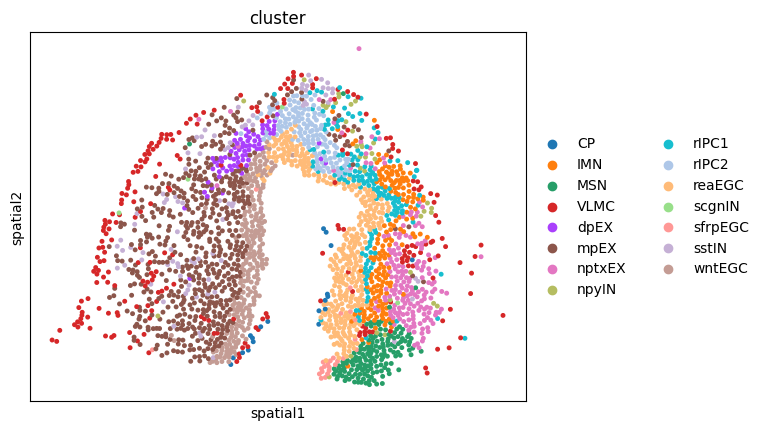

In [6]:
sc.pl.embedding(adata,basis='spatial',color=['cluster'])

In [7]:
adata = adata[adata.obs['total_counts']>2000]
adata = adata[adata.obs['n_genes_by_counts']>400]
print(adata)
print(adata.obs.cluster.value_counts())

View of AnnData object with n_obs × n_vars = 2182 × 32095
    obs: 'cluster', 'x', 'y', 'ID', 'n_genes_by_counts', 'total_counts'
    uns: 'cluster_colors'
    obsm: 'spatial'
cluster
mpEX       500
reaEGC     327
wntEGC     225
nptxEX     164
IMN        163
VLMC       156
MSN        152
rIPC1      144
rIPC2      134
sstIN       74
dpEX        70
npyIN       33
sfrpEGC     23
CP          14
scgnIN       3
Name: count, dtype: int64


In [8]:
adata_raw = adata.copy()
sc.pp.normalize_total(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True,flavor='seurat_v3')
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


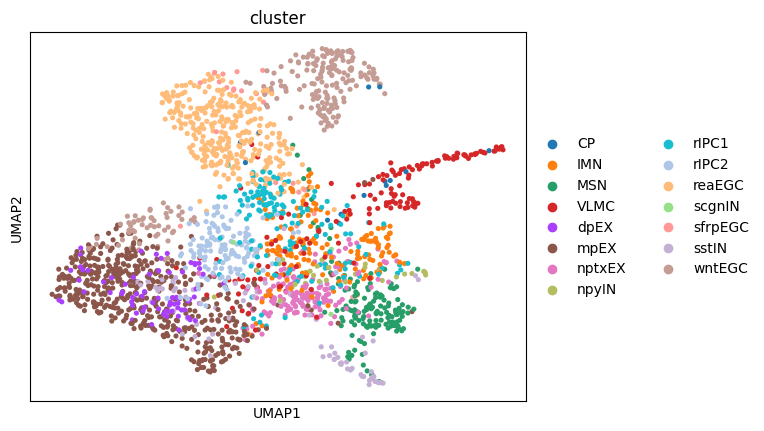

In [9]:
sc.pl.umap(adata,color=['cluster'])

In [10]:
#adata_lineage = adata[adata.obs.cluster.isin(['rIPC1','rIPC2','reaEGC'])]
adata_lineage = adata_raw[adata_raw.obs.cluster.isin(['rIPC1','rIPC2','reaEGC','dpEX','nptxEX','IMN'])]
adata_lineage

View of AnnData object with n_obs × n_vars = 1002 × 32095
    obs: 'cluster', 'x', 'y', 'ID', 'n_genes_by_counts', 'total_counts'
    uns: 'cluster_colors'
    obsm: 'spatial'

/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:172: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


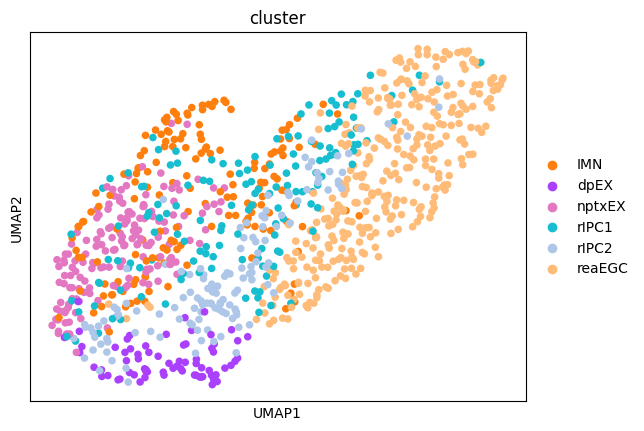

In [11]:
sc.pp.highly_variable_genes(adata_lineage, n_top_genes=2000, subset=True,flavor='seurat_v3')
sc.pp.pca(adata_lineage)
sc.pp.neighbors(adata_lineage)
sc.tl.umap(adata_lineage)
sc.pl.umap(adata_lineage,color=['cluster'])

In [12]:
adata_lineage.obs['lineage'] = adata_lineage.obs['cluster'].apply(
    lambda x: 'lineage1' if x in ['nptxEX', 'rIPC1','IMN'] else 'lineage2'

)

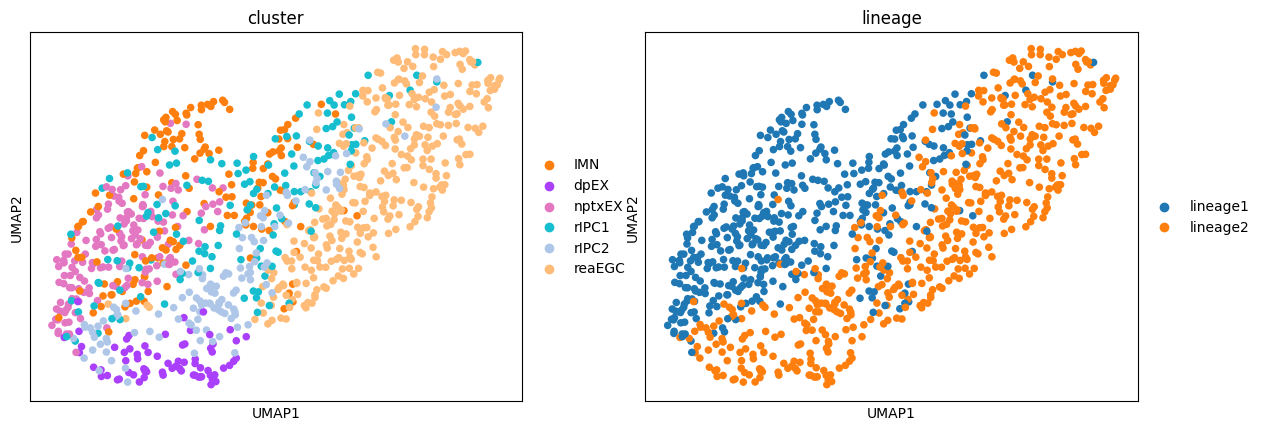

In [13]:
sc.pl.umap(adata_lineage,color=['cluster','lineage'])

In [14]:
adata_test = adata_lineage[adata_lineage.obs['cluster']=='reaEGC']
adata_train = adata_lineage[adata_lineage.obs['cluster'].isin(['dpEX','nptxEX','rIPC1','rIPC2','IMN'])]

adata_train = adata_lineage[adata_lineage.obs['cluster'].isin(['rIPC1','rIPC2'])]
#adata_train.obs.cluster = adata_train.obs.lineage
adata_train.obs['cluster'] = adata_train.obs['cluster'].astype('category')
train = Multimodal_Corpus(
    adata=adata_train,
    label_key = 'cluster',
    backed=False
)
test = Multimodal_Corpus(
    adata=adata_test,
    label_key = 'cluster',
    backed=False
)

hangar = Hangar('Ageas/data/configs/default_config_v1')

/tmp/ipykernel_244189/715203040.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_train.obs['cluster'] = adata_train.obs['cluster'].astype('category')


In [15]:
deck = n_kfold_selection(
    accelerator = 'cuda',
    query_dataset = train,
    kfold_selection_list = [2],
    hangar=hangar,
    monitor_metric = 'test.accuracy',
    retention_point = 0.5,
    verbose = True,
)

shutil.rmtree('cache')

/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test.CEL            0.5857298970222473
      test.accuracy         0.7214285731315613
       test.auroc           0.8204042911529541
         test.f1            0.6879520416259766
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test.CEL            0.2084217071533203
      test.accuracy         0.9714285731315613
       test.auroc           0.9797618389129639
         test.f1            0.9705056548118591
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
------------------------------------------------

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test.CEL            0.6850321888923645
      test.accuracy         0.5428571701049805
       test.auroc           0.6678489446640015
         test.f1            0.5064992308616638
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
------------------------------------------------

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test.CEL            0.2961324453353882
      test.accuracy         0.8928571343421936
       test.auroc           0.9599151611328125
         test.f1            0.8925983905792236
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/jiangjunyao/miniconda3/envs/ageas/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/

/tmp/ipykernel_244189/1457630102.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test.adata.obs['prob1'] = all_preds[:,0]


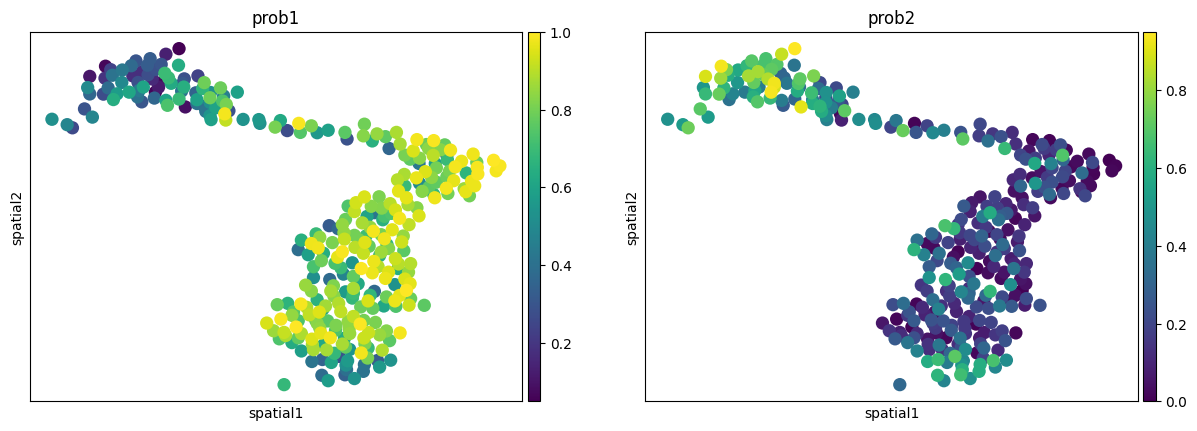

In [16]:
all_preds, all_labels = deck.predict(query_dataset = test)
def min_max_scaling(arr):

    min_val = np.min(arr)
    max_val = np.max(arr)
    scaled_arr = (arr - min_val) / (max_val - min_val)

    return scaled_arr
all_preds = min_max_scaling(all_preds)
test.adata.obs['prob1'] = all_preds[:,0]
test.adata.obs['prob2'] = all_preds[:,1]
sc.pl.embedding(test.adata,color=['prob1','prob2'],basis='spatial')

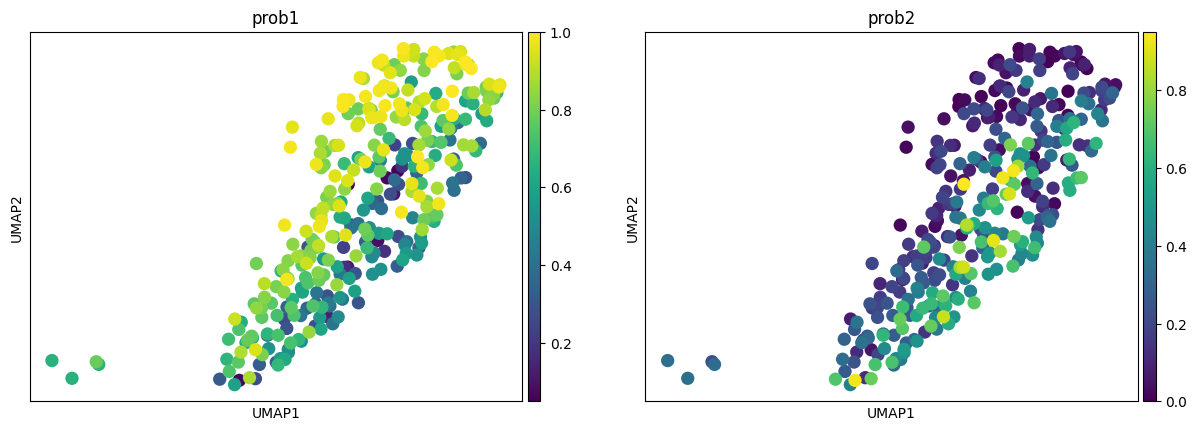

In [18]:
sc.pl.embedding(test.adata,color=['prob1','prob2'],basis='umap')